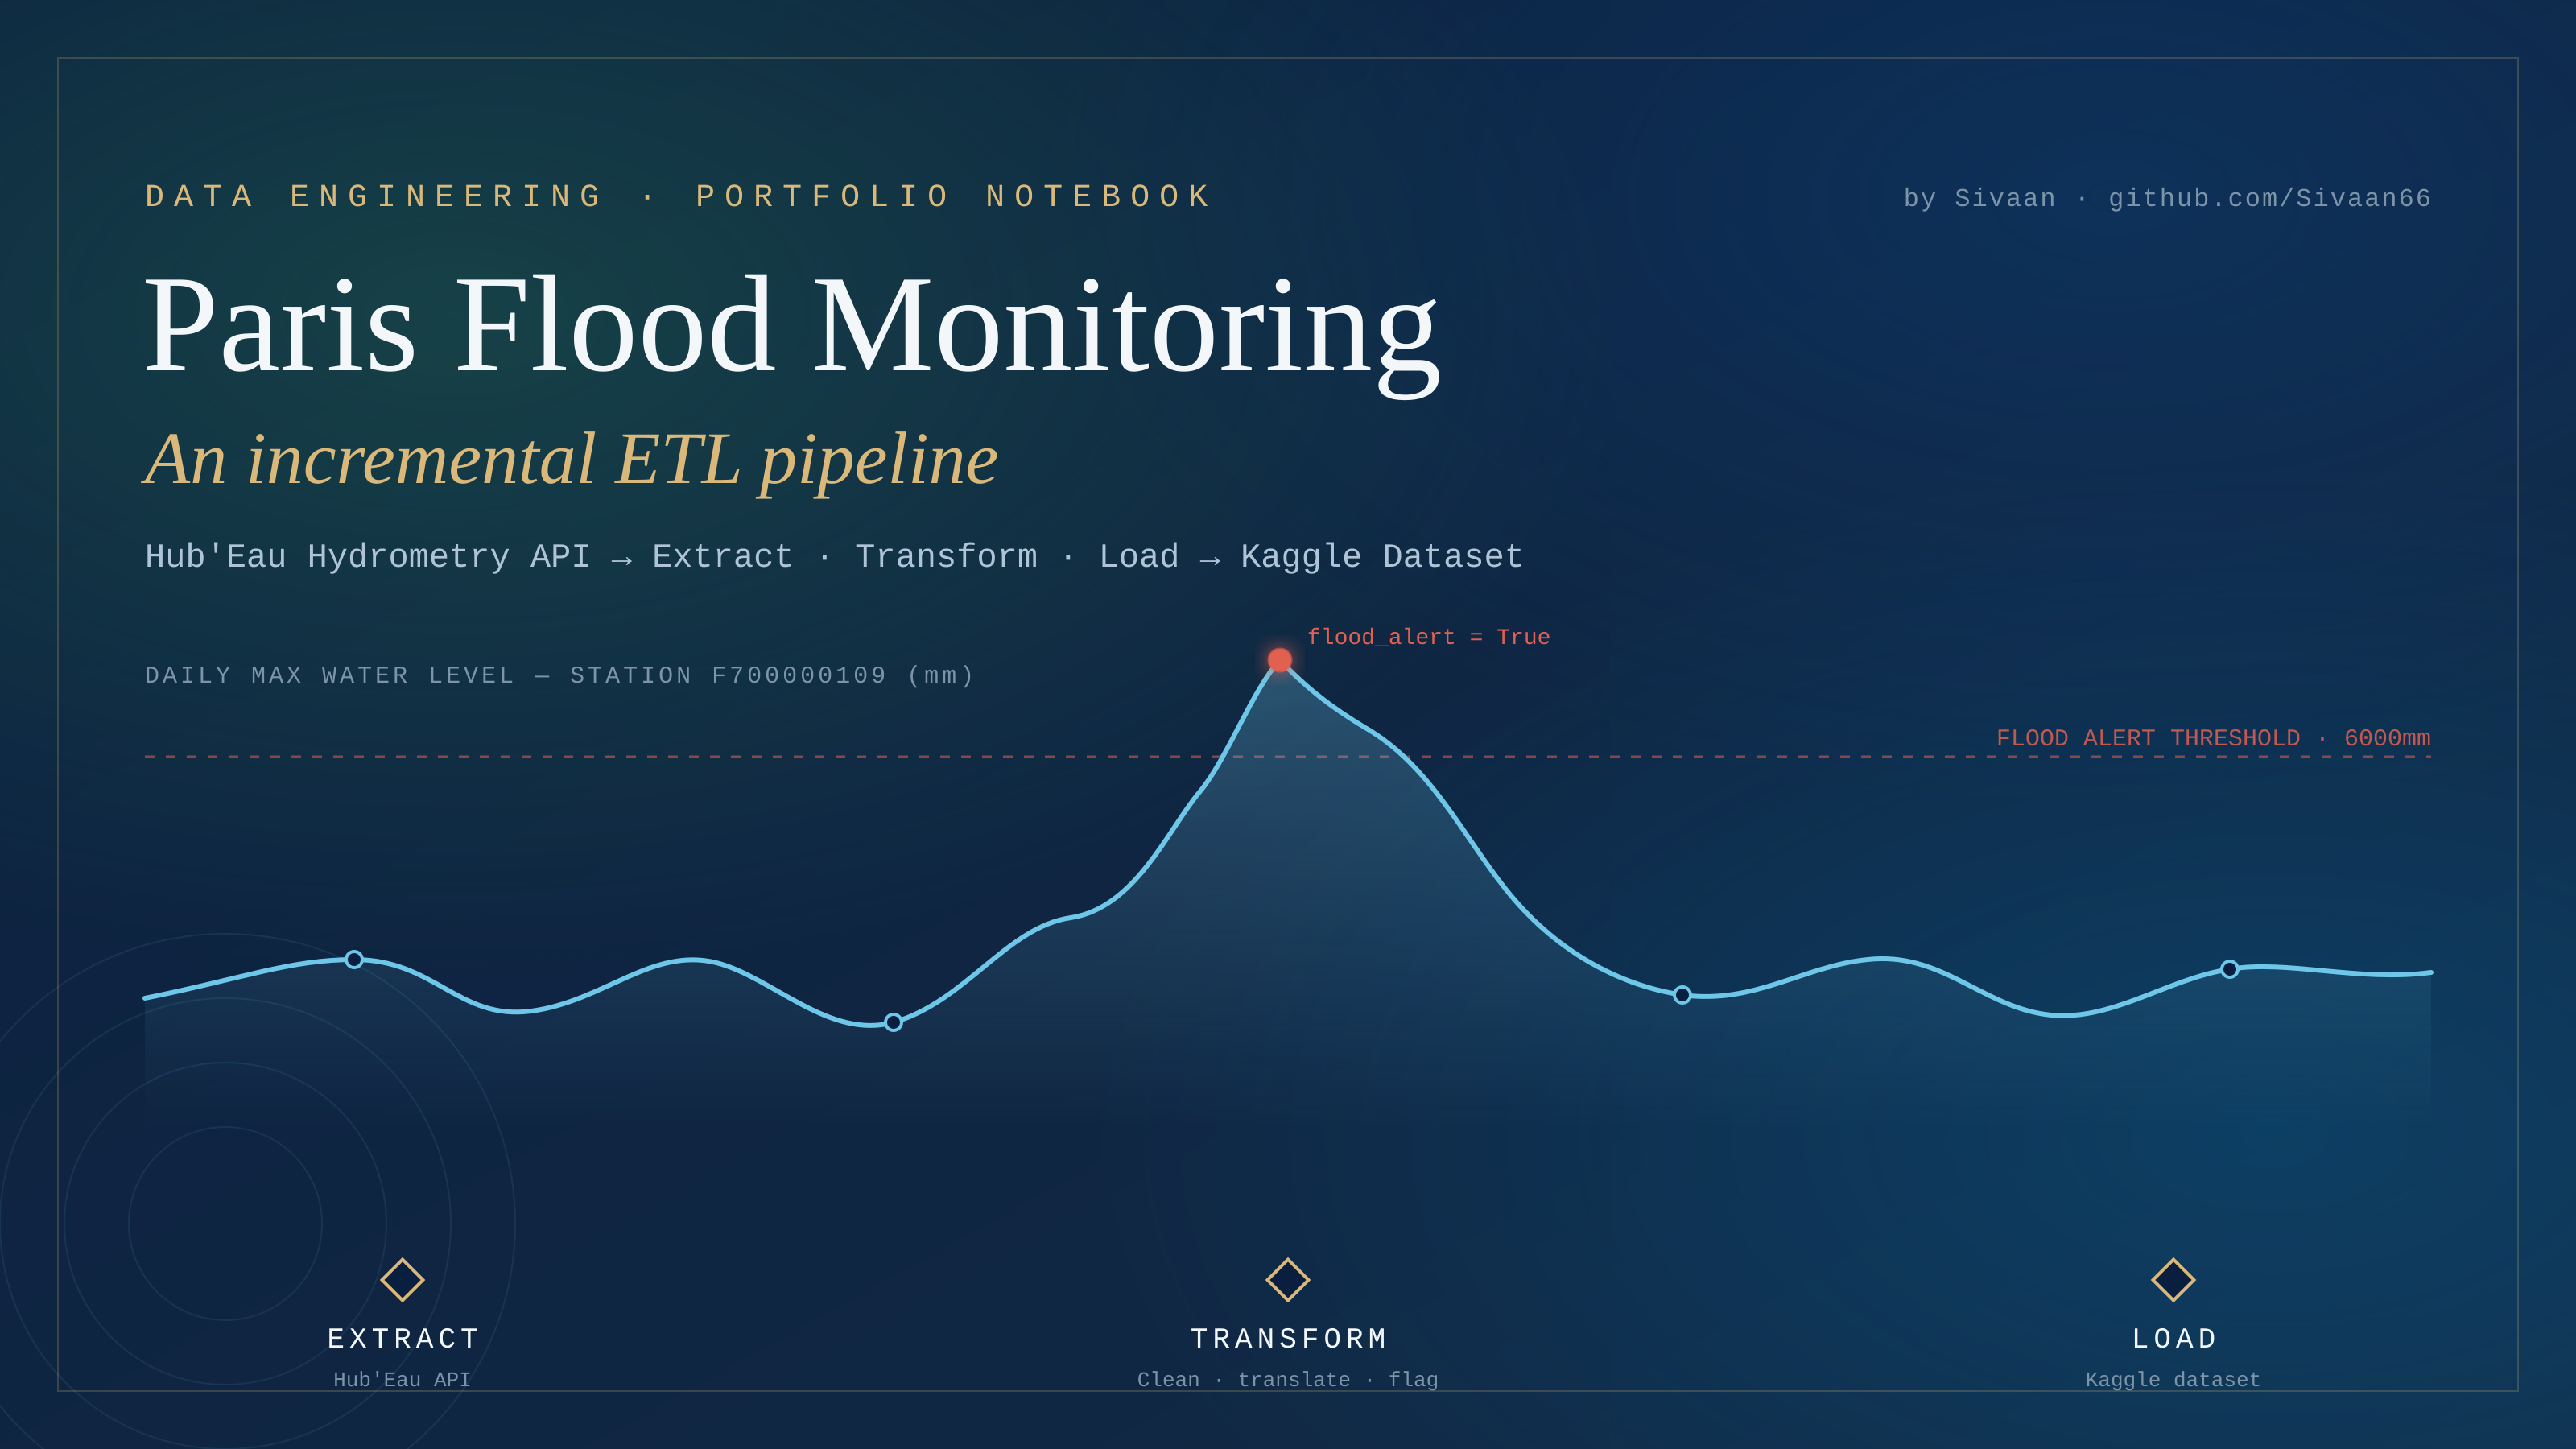


# 🌊 Paris Flood Monitoring — ETL Pipeline

### Hub'Eau Hydrometry API → Cleaned, Validated Dataset → Kaggle



---



## About this notebook



This notebook implements a complete **ETL (Extract, Transform, Load) pipeline** that keeps the

[Paris Flood dataset on Kaggle](https://www.kaggle.com/datasets/grimespoint/paris-flood-dataset) up to date.



It pulls **daily maximum water level readings** (the `HIXnJ` metric) for five monitoring stations around

Paris from the French government's [Hub'Eau Hydrometry API](https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab),

cleans and standardizes the data, flags potential flood events, and publishes the result as a

versioned CSV dataset on Kaggle.



**What makes this notebook self-contained and safe to re-run:**



| Property | Why it matters |

|---|---|

| **Incremental** | Only fetches data *after* the last date already in the dataset — no wasted API calls. |

| **Idempotent** | Deduplicates every run, so re-running never creates duplicate rows. |

| **Mock-first development** | Every function is prototyped and unit-tested against a synthetic mock API before touching the real one. |

| **Defensive** | Missing files, bad dates, and malformed values are handled gracefully instead of crashing the pipeline. |



> **Note:** Every code cell below is followed unchanged from the original implementation. Only the

> explanatory text (this markdown) has been added or rewritten for clarity.


## How the pipeline works



The notebook is organized around the three classic ETL stages, executed in this order every time the

pipeline runs:



### 1️⃣ Extract

Load whatever dataset already exists, figure out the date from which new data is actually needed

(so we never re-download data we already have), then call the Hub'Eau API — one station at a time —

to pull the missing daily records. A **mock API generator** stands in for the real API during

development and testing, so the whole pipeline can be exercised offline.



### 2️⃣ Transform

Raw API responses arrive in French, with inconsistent types and no derived signals. This stage:

- Coerces columns to proper `datetime` / numeric types (bad values become `NaT`/`NaN` instead of

  crashing the pipeline)

- Renames French API fields to clear English column names

- Translates French categorical labels (e.g. `"Donnée validée"` → `"validated"`)

- Computes a derived `flood_alert` flag from the configured threshold

- Reorders columns into a logical, readable layout

- Removes duplicate records using a composite key of `(station, date, water level)`

- Sorts and resets the index for a clean, publication-ready frame



### 3️⃣ Load

The cleaned dataset is written to CSV, a Kaggle-compatible `dataset-metadata.json` is generated

alongside it, and the new version is pushed to Kaggle via the `kaggle datasets version` CLI command.

A final validation pass checks the shape, types, null counts, and flood-alert statistics of the

published data.



Everything is tied together by a single orchestrator function, `run_etl_pipeline()`, which can run in

either **mock mode** (safe, offline, for development) or **live mode** (real API + real Kaggle publish).


## Pipeline structure map



The tree below maps every function and script section in this notebook to the ETL stage it belongs to,

in the order they appear.



```text

Paris Flood ETL Pipeline

│

├── ⚙️  SETUP

│   ├── Dependency imports (pandas, numpy, requests, ...)

│   └── Configuration dataclasses

│       ├── APIConfig        → Hub'Eau endpoint, metric, timeouts

│       ├── StationConfig     → station codes, flood threshold, earliest date

│       └── KaggleConfig      → dataset slug, output paths, metadata fields

│

├── 📥 EXTRACT

│   ├── load_csv()                 → safely load existing dataset (or empty frame)

│   ├── determine_date_range()     → decide if / from when new data is needed

│   ├── generate_mock_api_data()   → synthetic API responses for offline dev/testing

│   ├── signle_station_data()      → fetch (mock or real) data for one station

│   └── fetch_all_data()           → loop signle_station_data() over every configured station

│

├── 🔄 TRANSFORM

│   ├── Type parsing

│   │   ├── convert_to_date() / convert_to_numeric()   → explicit column coercion

│   │   └── auto_convert_columns()                     → automatic type inference

│   ├── Schema translation

│   │   ├── API_TO_EN / EN_TO_API                      → French ↔ English column maps

│   │   ├── CATEGORICAL_MAPPINGS                       → French ↔ English category labels

│   │   ├── rename_to_api_schema() / rename_to_english()

│   │   └── apply_categorical_mappings()

│   ├── Derived data

│   │   ├── add_derived_columns()                      → computes flood_alert flag

│   │   ├── COLUMN_ORDER                                → target column layout

│   │   └── order_columns()                             → applies the layout

│   ├── Deduplication

│   │   ├── create_dedup_key()                          → composite uniqueness key

│   │   └── remove_duplicates()                         → drops already-seen records

│   └── postprocess()              → orchestrates all of the above in sequence

│

├── 📤 LOAD

│   ├── create_dir()                → prepares the output directory

│   └── create_metadata()           → builds the Kaggle dataset-metadata.json content

│

└── 🚀 ORCHESTRATION

    ├── run_etl_pipeline()          → runs Extract → Transform → Load end-to-end

    ├── write_metadata()            → writes metadata JSON to disk

    ├── publish_to_kaggle()         → pushes the new dataset version via Kaggle CLI

    ├── validate_and_analyze()      → post-run data quality report

    ├── main()                      → wires everything together for a live run

    └── if __name__ == "__main__"   → script entry point

```


---

# Part 1 — Setup



## 1.1 Loading Dependencies



Import the standard library and third-party packages the pipeline relies on: `pandas`/`numpy` for data

handling, `requests` for the API calls, `dataclasses` for typed configuration, and `subprocess` for

invoking the Kaggle CLI later on. The `try/except` wrapper ensures a missing package produces a clear

error message instead of an unreadable traceback. Pandas display options are also widened so full

column names and values are visible in printed output.


In [417]:
try:
    import os
    import json
    import random
    import subprocess

    from dataclasses import dataclass, field
    from datetime import timedelta, date
    from pathlib import Path
    from typing import List, Dict, Set, Tuple, Optional

    import pandas as pd
    import numpy as np
    import requests

    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_colwidth', None)

    print("Executed and Loaded sussessfully")
    print("Pandas version:", pd.__version__)
    print("Numpy version:", np.__version__)
except Exception as e:
    print("Error while importing modules:", e)

Executed and Loaded sussessfully
Pandas version: 2.3.2
Numpy version: 2.3.2


## 1.2 Pipeline Configuration



All tunable settings live in three `dataclasses`, each with a single responsibility:



- **`APIConfig`** — the Hub'Eau endpoint URL, which metric to request (`HIXnJ` = daily max water

  level), pagination size, and network timeout. `__post_init__` guards against a zero timeout or

  page size.

- **`StationConfig`** — which station codes to monitor, the flood alert threshold (in mm), and the

  earliest date to backfill from when no data exists yet.

- **`KaggleConfig`** — everything related to the publishing destination: the dataset slug, input/output

  paths, filenames, and the metadata fields (title, keywords, license, update frequency) used when

  generating `dataset-metadata.json`. `__post_init__` resolves the final file paths once the other

  fields are known.



Instances of each are created immediately (`API_CONFIG`, `STATION_CONFIG`, `KAGGLE_CONFIG`) and reused

throughout the rest of the notebook.


In [418]:
@dataclass
class APIConfig:
    use_mock_data: bool = True
    base_url: str = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab"
    metric: str = "HIXnJ"  # Daily max water level (elaborated observations)
    max_rows_page: int = 20000
    timeout_sec: int = 60 # network timeout

    def __post_init__(self):
        if self.timeout_sec <= 0 :
            return ValueError("Time can not be Zero")
        if self.max_rows_page <= 0:
            return ValueError("Negative Data Quantity")

@dataclass
class StationConfig:
    code: List[str] = field(default_factory = lambda :[
        "F700000109",
        "F700000110",
        "F700000111",
        "F700000102",
        "F700000103",
    ])
    FloodThreshold_mm : int = 6000
    earliest_date : str = "1900-01-01"

@dataclass
class KaggleConfig:
    dataset_slug: str = "sibanandapathy/paris-flood-dataset"
    input_csv: str = "/kaggle/input/datasets/{slug}/paris_flood_dataset.csv"
    output_dir: Path = field(default_factory=lambda: Path("kaggle_dataset"))
    mock_output_dir: Path = field(default_factory=lambda: Path(
        "mock_output"))
    output_filename: str = "paris_flood_dataset.csv"
    mock_output_filename: str = "mock_flood_dataset.csv"
    metadata_filename : str = "dataset-metadata.json"

    # For metadata

    title:str = "Paris flood dataset"
    keywords: List = field(default_factory= lambda:
    ["tabular", "weather and climate", "environment", "europe", "time series analysis"])
    geospatial_coverage :str = "Paris, France"
    update_frequency: str = "weekly"
    liscence_name : str = "CC0-1.0"

    # computing files

    output_csv_path : Path = field(init=False)
    matadata_path : Path = field(init=False)

    def __post_init__(self):
        self.input_csv = self.input_csv.format(slug=self.dataset_slug)
        self.output_csv_path = self.output_dir / self.output_filename
        self.mock_csv_path = self.mock_output_dir / self.mock_output_filename
        self.metadata_path = self.output_dir / self.metadata_filename

# Initialising Configurations

API_CONFIG = APIConfig()
STATION_CONFIG = StationConfig()
KAGGLE_CONFIG = KaggleConfig()

print("Configurations initialized")
print(f"  - Monitoring {len(STATION_CONFIG.code)} stations")
print(f"  - Flood alert at: {STATION_CONFIG.FloodThreshold_mm}mm")
print(f"  - Publishing to: kaggle.com/{KAGGLE_CONFIG.dataset_slug}")

Configurations initialized
  - Monitoring 5 stations
  - Flood alert at: 6000mm
  - Publishing to: kaggle.com/sibanandapathy/paris-flood-dataset


A quick sanity check on the resolved output paths computed inside `KaggleConfig.__post_init__` —

confirming the CSV will land in the right place for both the live output directory and the mock

output directory used during testing.


In [419]:
print(KAGGLE_CONFIG.output_csv_path)
print(KAGGLE_CONFIG.mock_csv_path)

kaggle_dataset\paris_flood_dataset.csv
mock_output\mock_flood_dataset.csv


---

# Part 2 — Extract



## 2.1 Loading Existing Data — `load_csv()`



Before fetching anything new, the pipeline needs to know what data already exists. `load_csv()` reads

the dataset from disk if the path exists; if it doesn't (e.g. first-ever run), it returns an **empty

DataFrame** rather than raising an error or returning `None`.



> **Design note:** returning a consistent type (`DataFrame`) from every code path — instead of

> sometimes `None` — means every caller downstream can safely check `df.empty` without an extra

> `is None` check.


In [420]:
def load_csv(path: str):
    if os.path.exists(path):
        return pd.read_csv(path, low_memory=False, parse_dates= True, delimiter=",")
    return pd.DataFrame()

**Test —** loading from a path that doesn't exist should return an empty `DataFrame`, not crash. This

confirms `load_csv()` behaves safely and that the pipeline correctly interprets an empty frame as

"no existing data, do a full historical fetch."


In [421]:
# Test : load from a path that does not exist → empty DataFrame, no crash
df_missing = load_csv("/tmp/does_not_exist.csv")
print(f"Type    : {type(df_missing)}")
print(f"Shape   : {df_missing.shape}")
print(f"Empty?  : {df_missing.empty}")

# This means callers can always do df.empty instead of 'if df is None'
if df_missing.empty:
    print("No existing data. Will run a full fetch from earliest date.")

Type    : <class 'pandas.core.frame.DataFrame'>
Shape   : (0, 0)
Empty?  : True
No existing data. Will run a full fetch from earliest date.


## 2.2 Determining the Update Window — `determine_date_range()`



Given the currently loaded dataset, this function decides **whether** an update is needed and, if so,

**from which date** to resume fetching:



- No existing data → fetch everything from `STATION_CONFIG.earliest_date`.

- Existing data already covers up to yesterday → no update needed, exit early.

- Otherwise → resume from the day *after* the most recent record.



This is what makes the pipeline **incremental**: it never re-downloads data it already has.


In [422]:
def determine_date_range(existing: pd.DataFrame) -> Tuple[ bool, Optional[str]]:

    if existing.empty :
        print("No Dataset Avilable, Will Retrive from earliest date")
        return True, STATION_CONFIG.earliest_date

    if "date_obs_elab" in existing.columns :
        record_colname = "date_obs_elab"
    elif "record_date" in existing.columns :
        record_colname = "record_date"
    else:
        raise KeyError(
            "Missing date column: expected 'date_obs_elab' or 'record_date'"
        )

    s = pd.to_datetime(existing[record_colname], errors="coerce")

    last_day = s.max().date()
    yesterday = date.today() - timedelta(days = 1)

    print(f"Last day in dataset: {last_day}")
    print(f"Yesterday: {yesterday}")

    #case1
    if last_day >= yesterday:
        print("Data already Loaded, No updates required")
        return False, None

    next_day = last_day + pd.Timedelta(days = 1)
    print(f"\nWill retrieve data starting from: {next_day}")
    return True, next_day.isoformat()

### Testing `determine_date_range()`



Three scenarios are exercised to confirm the logic branches correctly:

1. **No existing data** — should trigger a full fetch from the earliest configured date.

2. **Old existing data** — should resume from the day after the last recorded date.

3. **Recent data that already covers yesterday** — should report no update is needed.


In [423]:
# Test 1: No existing data
print("=== Test 1: No existing data ===")
should_update, start_date = determine_date_range(pd.DataFrame())
print(f"Should update: {should_update}, Start from: {start_date}\n")

# Test 2: Old existing data
print("=== Test 2: Old existing data (Jan 10-15) ===")
old_data = pd.DataFrame({
    "date_obs_elab": pd.date_range("2026-01-10", periods=6),
    "code_station": ["F700000109"] * 6,
    "resultat_obs_elab": [5800.0] * 6,
})
should_update, start_date = determine_date_range(old_data)
print(f"Should update: {should_update}, Start from: {start_date}\n")

# Test 3: Recent existing data (covers yesterday)
print("=== Test 3: Recent data (covers yesterday) ===")
yesterday = date.today() - timedelta(days=1)
recent_data = pd.DataFrame({
    "date_obs_elab": pd.date_range(yesterday - timedelta(days=5), yesterday),
    "code_station": ["F700000109"] * 6,
    "resultat_obs_elab": [5800.0] * 6,
})
should_update, start_date = determine_date_range(recent_data)
print(f"Should update: {should_update}, Start from: {start_date}")

=== Test 1: No existing data ===
No Dataset Avilable, Will Retrive from earliest date
Should update: True, Start from: 1900-01-01

=== Test 2: Old existing data (Jan 10-15) ===
Last day in dataset: 2026-01-15
Yesterday: 2026-08-01

Will retrieve data starting from: 2026-01-16
Should update: True, Start from: 2026-01-16

=== Test 3: Recent data (covers yesterday) ===
Last day in dataset: 2026-08-01
Yesterday: 2026-08-01
Data already Loaded, No updates required
Should update: False, Start from: None


## 2.3 Mock Data Generator — `generate_mock_api_data()`



Rather than hitting the real Hub'Eau API during development, this function fabricates realistic-looking

API records: a plausible water level (with random noise), rotating validation/quality/method labels,

and coordinates jittered around central Paris. This lets the rest of the pipeline be built and tested

end-to-end **without any network calls**.


In [424]:
def generate_mock_api_data(station_code: str , start_date: str, num_days: int = 10): # Takes station code(str),start date(str),number of days of data to return(int) as input

    start = pd.to_datetime(start_date).date() # takes the start date as str input and return as date.time . date()( convert it into date)

    records = []

    # Creating property variables to append during the call
    validation_statuses = ["Donnée validée",
                           "Donnée brute", "Donnée pré-validée"]
    qualities = ["Bonne", "Non qualifiée", "Douteuse"]
    methods = ["Mesurée", "Calculée", "Expertisée"]


    # Running a loop for num_days times to return that much days of data.

    for i in range(num_days):
        obs_date = start + timedelta(days = i)

        # Exact water level simulation
        base_level = 5500 + int(station_code[-2:])
        noise = random.randint(-200,200)
        water_level = base_level + noise

        record = {
            "code_site": "mock_" + station_code[1:],
            "code_station": "mock_" + station_code,
            "date_obs_elab": obs_date.isoformat(),
            "resultat_obs_elab": water_level,
            "date_prod": (obs_date + timedelta(days=1)).isoformat(),
            "code_statut": "1",
            "libelle_statut": random.choice(validation_statuses),
            "code_methode": "1",
            "libelle_methode": random.choice(methods),
            "code_qualification": "1",
            "libelle_qualification": random.choice(qualities),
            "longitude": 2.3522 + random.uniform(-0.01, 0.01),
            "latitude": 48.8566 + random.uniform(-0.01, 0.01),
            "grandeur_hydro_elab": "mock_HIXnJ",
        }
        records.append(record)

    return records


### API call



Generating a small batch of mock records to confirm the function produces well-formed output — five

days of data for a single station, with the JSON structure of the first record printed for inspection.


In [425]:
mock_api_response = generate_mock_api_data(
    "F700000109", "2026-01-15", num_days=5)

print(f"Generated {len(mock_api_response)} mock API records")
print(f"\nSample record:")

print(json.dumps(mock_api_response[0], indent=2))

Generated 5 mock API records

Sample record:
{
  "code_site": "mock_700000109",
  "code_station": "mock_F700000109",
  "date_obs_elab": "2026-01-15",
  "resultat_obs_elab": 5550,
  "date_prod": "2026-01-16",
  "code_statut": "1",
  "libelle_statut": "Donn\u00e9e valid\u00e9e",
  "code_methode": "1",
  "libelle_methode": "Expertis\u00e9e",
  "code_qualification": "1",
  "libelle_qualification": "Douteuse",
  "longitude": 2.352572232666552,
  "latitude": 48.86055231824893,
  "grandeur_hydro_elab": "mock_HIXnJ"
}


## 2.4 Fetching a Single Station — `signle_station_data()`



Fetches data for **one station at a time** (later, results are appended together across stations). In

mock mode, it simply wraps `generate_mock_api_data()` in a DataFrame. In live mode, it pages through the

real Hub'Eau API using a persistent `requests.Session`, advancing the `cursor` date after each page

until the results reach yesterday's date or the API stops returning data.


In [426]:
def signle_station_data(start_date: str, station_code: str, use_mock : bool =True):

    if use_mock:
        data = generate_mock_api_data(station_code, start_date, num_days=7)
        page_df = pd.DataFrame(data)
        page_df["date_obs_elab"] = pd.to_datetime(page_df["date_obs_elab"], errors="coerce").dt.normalize()
        return page_df

    else:

        session = requests.Session()
        frame = []
        cursor = start_date

    while True:
        params = {
        "code_entite": station_code,
        "grandeur_hydro_elab": API_CONFIG.metric,
        "date_debut_obs_elab": cursor,
        "size": API_CONFIG.max_rows_page,
        }
        try:
            response = session.get(
                API_CONFIG.base_url,
                params= params,
                timeout= API_CONFIG.timeout_sec
            )   
            response.raise_for_status()

        except requests.RequestException as e:
            print(f"Error fetching station data {station_code} : {e}")
            break

        data = response.json().get("data", [])
        if not data:
            break
        page_df = pd.DataFrame(data)
        page_df["date_obs_elab"] = pd.to_datetime(page_df["date_obs_elab"], errors = "coerce" ).dt.normalize()
        frame.append(page_df)

        last_date = page_df["date_obs_elab"].max()
        yesterday = pd.Timestamp.today().normalize() - pd.Timedelta(days=1)

        if last_date >= yesterday or pd.isna(last_date):
            break

        cursor = (last_date + pd.Timedelta(days = 1)).strftime("%Y-%m-%d")

    if frame:
        return pd.concat(frame, ignore_index= True)
    return pd.DataFrame()



> **Best practice:** reuse a single `requests.Session` for multiple calls to the same host inside a

> loop — it keeps the underlying TCP connection alive instead of reconnecting on every request.



## 2.5 Fetching All Stations — `fetch_all_data()`



Loops `signle_station_data()` over every station code in `STATION_CONFIG.code`, collecting each

station's results and concatenating them into a single combined DataFrame of raw, un-transformed

records.


In [427]:
def fetch_all_data(start_date: str, use_mock: bool = True):

    frame = []

    for station_codes in STATION_CONFIG.code:
        print(f"fetching data for station code : {station_codes}...")
        df_station = signle_station_data(start_date, station_codes, use_mock = use_mock)

        if not df_station.empty:
            print(f"fetched {len(df_station)} records")
            frame.append(df_station)
        else :
            print(f"No data fetched")

        if frame:
            return pd.concat(frame, ignore_index= True)
        return pd.DataFrame()

**Test —** fetching mock data for all configured stations from a fixed start date, then previewing the

combined raw records (still in French/API column names at this point).


In [428]:
# Fetch fresh data
raw_data = fetch_all_data("2026-01-15", use_mock=True)

print(f"\nTotal raw records fetched: {len(raw_data)}")
print(f"\nFirst few rows (API schema):")
print(raw_data[["code_station", "date_obs_elab", "resultat_obs_elab"]].head())

fetching data for station code : F700000109...
fetched 7 records

Total raw records fetched: 7

First few rows (API schema):
      code_station date_obs_elab  resultat_obs_elab
0  mock_F700000109    2026-01-15               5582
1  mock_F700000109    2026-01-16               5328
2  mock_F700000109    2026-01-17               5591
3  mock_F700000109    2026-01-18               5587
4  mock_F700000109    2026-01-19               5590


---

# Part 3 — Transform



This section turns the raw, freshly-fetched data into a clean, publishable dataset. Each transformation

is written as a **pure function**: it takes a DataFrame and returns a new one, with no side effects.

Composing small, single-responsibility functions like this makes each step easy to test, debug, and

replace independently.



```text

    (EXTRACT)

    Raw API Data

    ↓

    (TRANSFORM)

1. Type parsing (datetime, numeric)

2. Column renaming (French → English)

3. Categorical mapping (validation status, quality)

4. Derived columns computation (flood alert flags)

5. Column reordering (logical grouping)

6. Sorting & index reset

    ↓

    (LOAD)

    Publication-ready dataset

```



## 3.1 Type Parsing — `convert_to_date()` / `convert_to_numeric()`



Two small utilities that coerce specific columns to `datetime` or numeric types respectively. Invalid

values (bad date strings, non-numeric text) are coerced to `NaT`/`NaN` instead of raising an exception,

so a handful of malformed rows never take down the whole pipeline.


In [429]:
def convert_to_date(df: pd.DataFrame, columns: List[str]):

    df = df.copy()

    for col in columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce").dt.normalize()

    return df

def convert_to_numeric(df: pd.DataFrame, columns: List[str]):

    df = df.copy()

    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors= "coerce")
    return df

**Test —** a deliberately messy DataFrame (including an invalid date string and a non-numeric value) is

passed through both converters. The "after" output shows the bad values cleanly coerced to `NaT`/`NaN`

rather than raising an error.


In [430]:
messy_df = pd.DataFrame({
    "date_obs_elab": ["2026-01-15", "2026-01-16", "not a date", None],
    "resultat_obs_elab": [5800.0, "5900", "N/A", None],
})

print("BEFORE type conversion:")
print(messy_df)
print(f"\nTypes: {messy_df.dtypes.to_dict()}")

type_safe_df = convert_to_date(messy_df, ["date_obs_elab"])
type_safe_df = convert_to_numeric(type_safe_df, ["resultat_obs_elab"])

print("\nAFTER type conversion:")
print(type_safe_df)
print(f"\nTypes: {type_safe_df.dtypes.to_dict()}")

print("\nBad values coerced to NaT/NaN (pipeline continues safely)")

BEFORE type conversion:
  date_obs_elab resultat_obs_elab
0    2026-01-15            5800.0
1    2026-01-16              5900
2    not a date               N/A
3          None              None

Types: {'date_obs_elab': dtype('O'), 'resultat_obs_elab': dtype('O')}

AFTER type conversion:
  date_obs_elab  resultat_obs_elab
0    2026-01-15             5800.0
1    2026-01-16             5900.0
2           NaT                NaN
3           NaT                NaN

Types: {'date_obs_elab': dtype('<M8[ns]'), 'resultat_obs_elab': dtype('float64')}

Bad values coerced to NaT/NaN (pipeline continues safely)


## 3.2 Automatic Type Inference — `auto_convert_columns()`



A more general version of the previous step: instead of naming columns explicitly, this function

inspects every object/string column, samples its values, and tries to parse them as dates first, then

as numbers, applying `convert_to_date()` / `convert_to_numeric()` only where the inference succeeds.

Columns that are already datetime or numeric are skipped.


In [431]:
def auto_convert_columns(df: pd.DataFrame):

    date_col = []
    numeric_col = []

    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            continue

        if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):

            sample = df[col].dropna().head(10)

            if len(sample) == 0:
                continue

            try:
                pd.to_datetime(df[col], errors="raise", format= "mixed")
                date_col.append(col)
                continue
            except(KeyError, ValueError):
                pass

            try:
                pd.to_numeric(df[col], errors = "raise")
                numeric_col.append(col)
                continue
            except (KeyError, ValueError):
                pass

    df = convert_to_date(df, date_col)
    df = convert_to_numeric(df, numeric_col)

    return df

## 3.3 Column Renaming Schema



Defines the mapping from the Hub'Eau API's French field names (e.g. `code_station`,

`resultat_obs_elab`) to clear English equivalents (e.g. `station_code`, `water_level_mm`). The reverse

mapping (`EN_TO_API`) is derived automatically, so the same dictionary drives translation in both

directions.


In [432]:
# ============================================================================
# SCHEMA MAPPINGS
# ============================================================================

# Primary mapping: French API columns to English column names
API_TO_EN = {
    "code_site": "location_code",
    "code_station": "station_code",
    "date_obs_elab": "record_date",
    "resultat_obs_elab": "water_level_mm",
    "date_prod": "data_production_date",
    "code_statut": "validation_status_code",
    "libelle_statut": "validation_status",
    "code_methode": "production_method_code",
    "libelle_methode": "production_method",
    "code_qualification": "quality_code",
    "libelle_qualification": "quality_assessment",
    "longitude": "longitude",
    "latitude": "latitude",
    "grandeur_hydro_elab": "hubeau_elab_code",
}
EN_TO_API = {v: k for k, v in API_TO_EN.items()}

print("API → English mapping sample:")
for api_col, en_col in list(API_TO_EN.items())[:5]:
    print(f"  {api_col:25} {en_col}")

print(f"\n{len(API_TO_EN)} column mappings defined")

API → English mapping sample:
  code_site                 location_code
  code_station              station_code
  date_obs_elab             record_date
  resultat_obs_elab         water_level_mm
  date_prod                 data_production_date

14 column mappings defined


## 3.4 Categorical Value Mappings



French categorical labels used by the API (validation status, quality assessment, production method)

are mapped to concise English equivalents — e.g. `"Donnée validée"` → `"validated"`, `"Bonne"` →

`"good"`. This keeps the published dataset consistent and easy to filter for English-speaking users.


In [433]:
# ============================================================================
# CATEGORICAL VALUE MAPPINGS
# ============================================================================

# Translation tables for categorical columns
CATEGORICAL_MAPPINGS = {
    "validation_status": {
        "Donnée validée": "validated",
        "Donnée brute": "raw",
        "Donnée pré-validée": "pre-validated",
    },
    "quality_assessment": {
        "Bonne": "good",
        "Non qualifiée": "unqualified",
        "Douteuse": "dubious",
    },
    "production_method": {
        "Calculée": "calculated",
        "Mesurée": "measured",
        "Expertisée": "expert-reviewed",
    },
}

print("Categorical mappings (French → English):")
for col_name, mapping in CATEGORICAL_MAPPINGS.items():
    print(f"\n  {col_name}:")
    for fr, en in mapping.items():
        print(f"    '{fr}' : '{en}'")

Categorical mappings (French → English):

  validation_status:
    'Donnée validée' : 'validated'
    'Donnée brute' : 'raw'
    'Donnée pré-validée' : 'pre-validated'

  quality_assessment:
    'Bonne' : 'good'
    'Non qualifiée' : 'unqualified'
    'Douteuse' : 'dubious'

  production_method:
    'Calculée' : 'calculated'
    'Mesurée' : 'measured'
    'Expertisée' : 'expert-reviewed'


## 3.5 Renaming Functions



`rename_to_api_schema()` and `rename_to_english()` apply the `API_TO_EN` / `EN_TO_API` maps from the

previous step to actually rename a DataFrame's columns. Both are defensive: they only rename columns

that are actually present, so they never error out on a partial or already-renamed frame.


In [434]:
def rename_to_api_schema(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    # Only rename columns that exist (defensive)
    columns_to_rename = {k: v for k, v in EN_TO_API.items() if k in df.columns}
    return df.rename(columns=columns_to_rename)


def rename_to_english(df: pd.DataFrame) -> pd.DataFrame:

    if df.empty:
        return df.copy()

    columns_to_rename = {}
    for src, dst in API_TO_EN.items():
        if src in df.columns and dst not in df.columns:
            columns_to_rename[src] = dst

    return df.rename(columns=columns_to_rename)

## 3.6 Applying Categorical Mappings — `apply_categorical_mappings()`



Applies the `CATEGORICAL_MAPPINGS` dictionary column-by-column, translating French category labels to

English. `.fillna()` on the mapped result preserves any value that wasn't found in the mapping table,

rather than turning it into `NaN`.


In [435]:

def apply_categorical_mappings(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()
    for col_name, mapping in CATEGORICAL_MAPPINGS.items():
        if col_name in df.columns:
            df[col_name] = df[col_name].map(mapping).fillna(df[col_name])
    return df

**Test —** confirms the rename is **bidirectional**: translating a sample French-schema frame to

English and back with `rename_to_api_schema()` should reproduce the original column names exactly.


In [436]:
# Test the functions
sample_api_df = pd.DataFrame({
    "code_station": ["F700000109"],
    "date_obs_elab": ["2024-01-15"],
    "resultat_obs_elab": [5800.0],
    "libelle_statut": ["Donnée validée"],
})

print("Original (API Schema):")
print(sample_api_df.columns.tolist())

renamed_df = rename_to_english(sample_api_df)
print("\nAfter rename_to_english():")
print(renamed_df.columns.tolist())

reversed_df = rename_to_api_schema(renamed_df)
print("\nAfter rename_to_api_schema() [should match original]:")
print(reversed_df.columns.tolist())

print("\nRound-trip rename successful (bidirectional mapping works).")

Original (API Schema):
['code_station', 'date_obs_elab', 'resultat_obs_elab', 'libelle_statut']

After rename_to_english():
['station_code', 'record_date', 'water_level_mm', 'validation_status']

After rename_to_api_schema() [should match original]:
['code_station', 'date_obs_elab', 'resultat_obs_elab', 'libelle_statut']

Round-trip rename successful (bidirectional mapping works).


## 3.7 Derived Columns — `add_derived_columns()`



Computes the pipeline's key derived signal: a boolean `flood_alert` column that flags any record whose

`water_level_mm` exceeds the configured `STATION_CONFIG.FloodThreshold_mm`.


In [437]:
def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "water_level_mm" in df.columns:
        df["flood_alert"] = df["water_level_mm"] > STATION_CONFIG.FloodThreshold_mm

    return df

## 3.8 Column Ordering Schema



Defines the final, human-friendly column order for the published dataset: identifiers and measurements

first (most important), then observation metadata, then geographic details last (least frequently

needed).


In [438]:
# ============================================================================
# COLUMN ORDERING
# ============================================================================

# User defined preferred column order (logical grouping)
COLUMN_ORDER = [
    # Primary identifiers & measurements
    "station_code",
    "record_date",
    "water_level_mm",
    "flood_alert",  # Derived metric (computed)

    # Metadata about the observation
    "hubeau_elab_code",
    "data_production_date",
    "validation_status_code",
    "validation_status",
    "production_method_code",
    "production_method",
    "quality_code",
    "quality_assessment",

    # Geographic info (less important)
    "location_code",
    "longitude",
    "latitude",
]

print(f"Column order defined: {len(COLUMN_ORDER)} columns")
print(f"Priority: IDs & measurements → metadata → geography")

Column order defined: 15 columns
Priority: IDs & measurements → metadata → geography


## 3.9 Applying Column Order — `order_columns()`



Reorders a DataFrame's columns according to `COLUMN_ORDER`, appending any columns not explicitly listed

at the end so nothing is ever silently dropped.


In [439]:
def order_columns(df: pd.DataFrame) -> pd.DataFrame:

    present_cols = [c for c in COLUMN_ORDER if c in df.columns]

    other_cols = [c for c in df.columns if c not in present_cols]

    return df[present_cols + other_cols]

## 3.10 Deduplication



### The problem: duplicate records



In an incremental pipeline, date ranges and records can overlap:

- We might re-fetch a day we already have (API data arrives late)

- The same observation might appear across two API pages

- The scheduled script might run twice by accident



Without deduplication, the dataset would accumulate duplicate rows over time.



### The solution: a composite deduplication key



```text

key = (station_code, observation_date, water_level_value)

```



This combination should be unique in the physical world — one sensor, one day, one daily maximum water

level reading:

- **station_code** — records from different stations can't be duplicates.

- **observation_date** — two readings on different days aren't duplicates.

- **water_level_mm** — same station + date but a different value is a different observation.



If two records share the same key, only the first occurrence is kept.



`create_dedup_key()` below builds this composite key as a single string per row.


In [440]:
def create_dedup_key(df: pd.DataFrame) -> pd.Series:

    parts = []


    if "code_station" in df.columns:
        parts.append(df["code_station"].astype(str))


    if "date_obs_elab" in df.columns:
        parts.append(df["date_obs_elab"].dt.strftime("%Y-%m-%d"))

    if "resultat_obs_elab" in df.columns:
        parts.append(df["resultat_obs_elab"].astype(str))

    if not parts:
        return pd.Series(index=df.index, dtype="object")


    return pd.Series(
        ["_".join(row) for row in zip(*parts)],
        index=df.index
    )

**Test —** confirms the generated keys are unique, human-readable strings that combine station, date,

and water level.


In [441]:
# Test
test_std_df = pd.DataFrame({
    "code_station": ["F700000109", "F700000110"],
    "date_obs_elab": pd.to_datetime(["2026-01-15", "2026-01-16"]),
    "resultat_obs_elab": [5800.0, 5900.0],
})

keys = create_dedup_key(test_std_df)
print("Deduplication Keys:")
print(keys.tolist())

print("\nKeys are unique, human-readable, and immutable")

Deduplication Keys:
['F700000109_2026-01-15_5800.0', 'F700000110_2026-01-16_5900.0']

Keys are unique, human-readable, and immutable


**Progress so far:**

1. Robust types (columns)

2. Robust dedup key



**Next step:** use the key to safely drop duplicates.



## Removing Duplicates — `remove_duplicates()`



Standardizes both the existing and newly-fetched frames, builds dedup keys for each, and keeps only the

new rows whose key **doesn't already appear** in the existing dataset. If either input is empty, the new

data is returned as-is (nothing to compare against).


In [442]:
def remove_duplicates(existing: pd.DataFrame, new: pd.DataFrame) -> pd.DataFrame:


    if existing.empty or new.empty:
        return new.copy()

    existing_std = auto_convert_columns(existing)
    new_std = auto_convert_columns(new)

    # Create dedup keys
    existing_keys = set(create_dedup_key(existing_std).dropna())
    new_keys = create_dedup_key(new_std)

    mask = ~new_keys.isin(existing_keys)

    result = new.iloc[new_keys[mask].index].copy()

    return result

**Test —** an existing dataset (2 rows) is compared against new data (3 rows, one of which duplicates

an existing row). The result should contain only the 2 genuinely new rows.


In [443]:

existing_test_data = pd.DataFrame({
    "code_station": ["F700000109", "F700000109"],
    "date_obs_elab": ["2026-01-15", "2026-01-16"],
    "resultat_obs_elab": [5800.0, 5850.0],
})

new_test_data = pd.DataFrame({
    "code_station": ["F700000109", "F700000109", "F700000110"],
    # First row is duplicate
    "date_obs_elab": ["2026-01-15", "2026-01-17", "2026-01-17"],
    "resultat_obs_elab": [5800.0, 5900.0, 6100.0],
})

print("Existing data (2 rows):")
print(existing_test_data)

print("\nNew data (3 rows, 1 is duplicate):")
print(new_test_data)

deduped = remove_duplicates(existing_test_data, new_test_data)

print("\nAfter deduplication (2 rows):")
print(deduped)

print(f"\nRemoved {len(new_test_data) - len(deduped)} duplicate row(s), will append these two rows to the existing dataset.")

Existing data (2 rows):
  code_station date_obs_elab  resultat_obs_elab
0   F700000109    2026-01-15             5800.0
1   F700000109    2026-01-16             5850.0

New data (3 rows, 1 is duplicate):
  code_station date_obs_elab  resultat_obs_elab
0   F700000109    2026-01-15             5800.0
1   F700000109    2026-01-17             5900.0
2   F700000110    2026-01-17             6100.0

After deduplication (2 rows):
  code_station date_obs_elab  resultat_obs_elab
1   F700000109    2026-01-17             5900.0
2   F700000110    2026-01-17             6100.0

Removed 1 duplicate row(s), will append these two rows to the existing dataset.


## 3.11 Full Postprocessing Pipeline — `postprocess()`



Chains together every transformation built above, in order, into a single entry point:



1. `auto_convert_columns()` — enforce datetime/numeric types

2. `rename_to_english()` — translate column names

3. `apply_categorical_mappings()` — translate category labels

4. `add_derived_columns()` — compute `flood_alert`

5. `order_columns()` — apply the logical column layout

6. Sort by date and station, then reset the index



The result is a fully clean, English-schema, publication-ready DataFrame.


In [444]:
def postprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all post-processing transformations.

    The complete "Transform" pipeline:
    1. Enforce datetime and numeric types
    2. Rename to English schema
    3. Translate categorical values
    4. Add derived columns
    5. Reorder columns logically
    6. Sort by date and station & reset index

    Args:
        df: Raw API data (French schema)

    Returns:
        Fully processed, publication-ready dataset
    """
    if df.empty:
        return df

    df = df.copy()

    # Step 1: Type conversions
    print("  1. Converting types...")
    df = auto_convert_columns(df)

    # Step 2: Rename columns
    print("  2. Renaming columns (French → English)...")
    df = rename_to_english(df)

    # Step 3: Map categories
    print("  3. Mapping categorical values...")
    df = apply_categorical_mappings(df)

    # Step 4: Add computed columns
    print("  4. Adding derived columns...")
    df = add_derived_columns(df)

    # Step 5: Organize columns
    print("  5. Reordering columns...")
    df = order_columns(df)

    # Step 6: Sort and reset index
    print("  6. Sorting and resetting index...")
    df = df.sort_values(["record_date", "station_code"]).reset_index(drop=True)

    return df

**Test —** runs the raw mock data collected earlier through the full `postprocess()` pipeline and

inspects the first row and final column order to confirm every transformation applied correctly.


In [445]:
# Test the full postprocessing pipeline
print("Processing raw API data...")
raw_data_fr = rename_to_english(raw_data)
raw_data_fr = apply_categorical_mappings(raw_data_fr)

processed_mock_data = postprocess(raw_data_fr)

print(f"\nProcessing complete: {len(processed_mock_data)} rows")
print(f"\nFirst row (processed, English schema):")
print(processed_mock_data.iloc[0])

print(f"\nColumn order verified: ")
print(processed_mock_data.columns.tolist())

Processing raw API data...
  1. Converting types...
  2. Renaming columns (French → English)...
  3. Mapping categorical values...
  4. Adding derived columns...
  5. Reordering columns...
  6. Sorting and resetting index...

Processing complete: 7 rows

First row (processed, English schema):
station_code                  mock_F700000109
record_date               2026-01-15 00:00:00
water_level_mm                           5582
flood_alert                             False
hubeau_elab_code                   mock_HIXnJ
data_production_date      2026-01-16 00:00:00
validation_status_code                      1
validation_status                         raw
production_method_code                      1
production_method             expert-reviewed
quality_code                                1
quality_assessment                    dubious
location_code                  mock_700000109
longitude                            2.346597
latitude                            48.863183
Name: 0, dtype: 

---

# Part 4 — Load



This is the final stage of the ETL pipeline: taking the processed data from the transform phase and

moving it into a target system or destination — typically a data warehouse, data lake, database, data

mart, or BI tool.



Here, the mock pipeline saves a CSV locally for demo purposes, while the live pipeline replicates the

[original script's](https://www.kaggle.com/code/grimespoint/paris-flood-dataset-weekly-updater)

behavior and updates the real

[Paris Flood dataset](https://www.kaggle.com/datasets/grimespoint/paris-flood-dataset) on Kaggle.



> 📌 If you run a copy of this notebook in your own environment, make sure you have your own copy of

> the dataset and **update the paths and slugs** in `KaggleConfig` to point to your own locations.



## 4.1 Preparing Output Directories — `create_dir()`



Ensures the destination folder (mock or live, depending on the `use_mock` flag) exists before anything

is written to it, creating parent directories as needed.


In [446]:
def create_dir(use_mock: bool = False):

    output_dir = KAGGLE_CONFIG.mock_output_dir if use_mock else KAGGLE_CONFIG.output_dir
    output_dir.mkdir(parents=True, exist_ok=True)


Creating the **live** output directory (`use_mock=False`), since this is the one the final pipeline run

will actually publish to.


In [447]:
create_dir(use_mock=False)

## 4.2 Building Kaggle Metadata — `create_metadata()`



Generates the `dataset-metadata.json` content Kaggle requires to publish a dataset version: title,

dataset ID, license, keywords, geographic coverage, update frequency, and — computed directly from the

data — the temporal coverage (earliest and latest `record_date`). The cell also demonstrates the full

round trip: generating the metadata for the mock dataset, printing it, and writing it to the mock output

directory.


In [448]:
def create_metadata(df: pd.DataFrame, config: KaggleConfig) -> Dict:
    """Generate Kaggle dataset metadata from DataFrame and config.

    - Dataset discoverability (keywords, title)
    - Usage rights (license)
    - Data freshness (temporal coverage)
    - Geographic context

    Args:
        df: Processed DataFrame with 'record_date' column
        config: KaggleConfig instance

    Returns:
        Dictionary in Kaggle-compatible format
    """
    if df.empty or "record_date" not in df.columns:
        first_date = "unknown"
        last_date = "unknown"
    else:
        first_date = df["record_date"].min().strftime("%Y-%m-%d")
        last_date = df["record_date"].max().strftime("%Y-%m-%d")

    metadata = {
        "title": config.title,
        "id": config.dataset_slug,
        "subtitle": "Historical flood and climate data for Paris, France from 1900 to 1965",
        "licenses": [{"name": config.liscence_name}],
        "keywords": config.keywords,
        "temporalCoverage": {
            "startDate": first_date,
            "endDate": last_date,
        },
        "geospatialCoverage": config.geospatial_coverage,
        "updateFrequency": config.update_frequency,
    }

    return metadata

# Generate metadata
create_dir(use_mock=True)
metadata = create_metadata(processed_mock_data, KAGGLE_CONFIG)

print("Dataset Metadata:")
print(json.dumps(metadata, indent=2))

# Save metadata to JSON
metadata_path = KAGGLE_CONFIG.mock_output_dir
dataset_meta_file = metadata_path / KAGGLE_CONFIG.metadata_filename

with open(dataset_meta_file, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"\nMetadata saved to {metadata_path}")

Dataset Metadata:
{
  "title": "Paris flood dataset",
  "id": "sibanandapathy/paris-flood-dataset",
  "subtitle": "Historical flood and climate data for Paris, France from 1900 to 1965",
  "licenses": [
    {
      "name": "CC0-1.0"
    }
  ],
  "keywords": [
    "tabular",
    "weather and climate",
    "environment",
    "europe",
    "time series analysis"
  ],
  "temporalCoverage": {
    "startDate": "2026-01-15",
    "endDate": "2026-01-21"
  },
  "geospatialCoverage": "Paris, France",
  "updateFrequency": "weekly"
}

Metadata saved to mock_output


---

# Part 5 — Orchestration



With every Extract, Transform, and Load building block in place, this section assembles them into a

single, runnable pipeline — first proven safe in mock mode, then run for real.



A reminder of the mock data generated earlier, which stands in for a real API response during the mock

run below.


In [449]:
print(mock_api_response)

[{'code_site': 'mock_700000109', 'code_station': 'mock_F700000109', 'date_obs_elab': '2026-01-15', 'resultat_obs_elab': 5550, 'date_prod': '2026-01-16', 'code_statut': '1', 'libelle_statut': 'Donnée validée', 'code_methode': '1', 'libelle_methode': 'Expertisée', 'code_qualification': '1', 'libelle_qualification': 'Douteuse', 'longitude': 2.352572232666552, 'latitude': 48.86055231824893, 'grandeur_hydro_elab': 'mock_HIXnJ'}, {'code_site': 'mock_700000109', 'code_station': 'mock_F700000109', 'date_obs_elab': '2026-01-16', 'resultat_obs_elab': 5354, 'date_prod': '2026-01-17', 'code_statut': '1', 'libelle_statut': 'Donnée brute', 'code_methode': '1', 'libelle_methode': 'Calculée', 'code_qualification': '1', 'libelle_qualification': 'Douteuse', 'longitude': 2.3548987714259977, 'latitude': 48.84782506286777, 'grandeur_hydro_elab': 'mock_HIXnJ'}, {'code_site': 'mock_700000109', 'code_station': 'mock_F700000109', 'date_obs_elab': '2026-01-17', 'resultat_obs_elab': 5570, 'date_prod': '2026-01-1

## 5.1 The ETL Orchestrator — `run_etl_pipeline()`



Runs the complete pipeline end-to-end, returning the final processed DataFrame:



1. **Load** the existing dataset (mock sample or real CSV, depending on `use_mock`)

2. **Determine** whether an update is needed, and from what date

3. **Extract** new records from that date onward — exits early if already up to date

4. *(continues in the next steps below: deduplicate, merge, postprocess, save, publish)*



This function is the backbone that ties `load_csv()`, `determine_date_range()`, `fetch_all_data()`,

`remove_duplicates()`, and `postprocess()` together into one call.


In [450]:
def run_etl_pipeline(use_mock: bool = True) -> pd.DataFrame:
    """Run the complete ETL pipeline: Extract → Transform → Load to CSV.

    Returns:
        Processed DataFrame ready for publication
    """
    print("\n" + "="*70)
    print("PARIS FLOOD DATASET ETL PIPELINE")
    print("="*70)

    # ====================================================================
    # STEP 1: LOAD EXISTING DATA
    # ====================================================================

    if use_mock:
        print("\n=== mock pipeline ===")
        print("\n[STEP 1] Loading mock dataset...")
        # For demo, use a sample existing dataset
        loaded_df = pd.DataFrame(mock_api_response)
        loaded_df['date_obs_elab'] = pd.to_datetime(loaded_df['date_obs_elab'])

        # Demo : translate in english here (mimic loaded CSV)
        loaded_df = rename_to_english(loaded_df)
        print(f"  Loaded {len(loaded_df)} existing records")

    else:
        print("\n=== API pipeline ===")
        print("\n[STEP 1] Loading existing dataset...")
        loaded_df = load_csv(KAGGLE_CONFIG.input_csv)
        print(f"  {len(loaded_df):,} existing rows loaded.")

    # ====================================================================
    # STEP 2: DETERMINE UPDATE RANGE
    # ====================================================================
    print("\n[STEP 2] Determining update range...")
    should_update, start_date = determine_date_range(loaded_df)
    if not should_update:
        print("\n Dataset is current. Returning existing data.")
        return loaded_df

    # ====================================================================
    # STEP 3: EXTRACT (FETCH DATA)
    # ====================================================================
    print(f"\n[STEP 3] Extracting data from {start_date})...")
    fetched_data = fetch_all_data(start_date, use_mock=use_mock)
    print(f"  Extracted {len(fetched_data)} raw records")

    # ====================================================================
    # STEP 4: TRANSFORM I : DEDUPLICATE
    # ====================================================================
    print("\n[STEP 4] Deduplicating against existing data...")
    deduped_fetched_data = remove_duplicates(loaded_df, fetched_data)
    print(f"  Removed {len(fetched_data) - len(deduped_fetched_data)} duplicates")
    print(f"  {len(deduped_fetched_data)} truly new records to add")

    # ====================================================================
    # STEP 5: TRANSFORM II : COMBINE (MERGE WITH EXISTING)
    # ====================================================================
    print("\n[STEP 5] Merging new data with existing...")
    # Translate fetched data into English (match loaded_df) before combining
    new_df_english = rename_to_english(deduped_fetched_data)
    merged_historical_and_new = pd.concat([loaded_df, new_df_english], ignore_index=True)
    print(f"  Combined dataset: {len(merged_historical_and_new)} total records")

    # ====================================================================
    # STEP 6: TRANSFORM III : POST-PROCESS
    # ====================================================================
    print("\n[STEP 6] Postprocessing data...")
    processed_records = postprocess(merged_historical_and_new)
    print(f"  Transformation complete")

    # ====================================================================
    # STEP 7: EXPORT (LOAD TO CSV)
    # Mock exports only mock CSV
    # For real world behaviour, set mock=False in the later section
    # ====================================================================
    print("\n[STEP 7] Exporting to CSV...")

    create_dir(use_mock=use_mock)

    if use_mock:
        output_path = KAGGLE_CONFIG.mock_csv_path
    else:
        output_path = KAGGLE_CONFIG.output_csv_path

    processed_records.to_csv(output_path, index=False, sep=",")

    file_size_kb = os.path.getsize(output_path) / 1024
    print(f"  Exported to {output_path}")
    print(f"  File size: {file_size_kb:.1f} KB")

    print("\n" + "="*70)
    print("ETL PIPELINE COMPLETE")
    print("="*70)

    return processed_records


# Run the pipeline
mock_dataset = run_etl_pipeline(use_mock=True)


PARIS FLOOD DATASET ETL PIPELINE

=== mock pipeline ===

[STEP 1] Loading mock dataset...
  Loaded 5 existing records

[STEP 2] Determining update range...
Last day in dataset: 2026-01-19
Yesterday: 2026-08-01

Will retrieve data starting from: 2026-01-20

[STEP 3] Extracting data from 2026-01-20)...
fetching data for station code : F700000109...
fetched 7 records
  Extracted 7 raw records

[STEP 4] Deduplicating against existing data...
  Removed 0 duplicates
  7 truly new records to add

[STEP 5] Merging new data with existing...
  Combined dataset: 12 total records

[STEP 6] Postprocessing data...
  1. Converting types...
  2. Renaming columns (French → English)...
  3. Mapping categorical values...
  4. Adding derived columns...
  5. Reordering columns...
  6. Sorting and resetting index...
  Transformation complete

[STEP 7] Exporting to CSV...
  Exported to mock_output\mock_flood_dataset.csv
  File size: 2.0 KB

ETL PIPELINE COMPLETE


### 5.2 Pipeline flow, end to end



The full sequence `run_etl_pipeline()` executes internally, laid out step by step for clarity:



```python

loaded_df                 = load_csv(...)                          # 1. load existing data

should_update, start_date = determine_update_range(...)            # 2. check what's needed

fetched_data               = fetch_all_data(start_date)             # 3. fetch new records

deduped_fetched_data       = remove_duplicates(existing, new_raw)   # 4. deduplicate

merged_historical_and_new  = pd.concat([existing, new_clean])       # 5. merge

processed_records          = postprocess(merged_historical_and_new) # 6. postprocess

processed_records.to_csv(...)                                       # 7. save

write_metadata() + publish_to_kaggle()                              # 8. publish

```



Linear, and each step's intent is obvious — which is the point of decomposing the pipeline into small,

single-purpose functions.



### The real deal



The functions below wire this flow up to the **live** run: writing the final CSV, generating and saving

metadata, publishing to Kaggle, and validating the result.



## 5.3 Writing Metadata — `write_metadata()`



Calls `create_metadata()` to build the metadata dictionary for the final processed dataset, then writes

it to `KAGGLE_CONFIG.metadata_path` as JSON.


In [451]:
def write_metadata(df: pd.DataFrame) -> None:
    """Write dataset metadata to JSON file.

    Calls create_metadata to generate content and writes to path specified
    in KAGGLE_CONFIG.metadata_path.

    Args:
        df (pd.DataFrame): Processed DataFrame to extract temporal coverage from.

    Raises:
        IOError: If file writing fails.
    """
    metadata = create_metadata(df, KAGGLE_CONFIG)

    with open(KAGGLE_CONFIG.metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    print(f"Metadata written to {KAGGLE_CONFIG.metadata_path}")

## 5.4 Publishing to Kaggle — `publish_to_kaggle()`



Shells out to the Kaggle CLI (`kaggle datasets version`) to push the updated output directory as a new

dataset version, tagging the commit message with the current timestamp. Any failure from the CLI is

logged and re-raised so it isn't silently swallowed.


In [452]:
def publish_to_kaggle() -> None:
    """Publish the updated dataset to Kaggle using the Kaggle CLI.

    Runs 'kaggle datasets version' command with current output directory.
    Includes timestamp in the version message.

    Raises:
        subprocess.CalledProcessError: If Kaggle CLI command fails.
    """
    timestamp = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    message = f"Weekly update: {timestamp}"

    cmd = [
        "kaggle",
        "datasets",
        "version",
        "-p",
        str(KAGGLE_CONFIG.output_dir),
        "-m",
        message,
        "--dir-mode",
        "zip",
    ]

    print("Publishing to Kaggle...")
    print("Command:", " ".join(cmd))

    try:
        subprocess.run(cmd, check=True)
        print("Successfully published to Kaggle.")
    except subprocess.CalledProcessError as e:
        print(f"Error publishing to Kaggle: {e}")
        raise

## 5.5 Post-Run Validation — `validate_and_analyze()`



A data-quality report run **after** the pipeline completes, printing:

- Dataset shape and column data types

- Null value counts (and percentages) per column

- Descriptive statistics for `water_level_mm`

- How many records exceed the flood threshold, and what percentage of the dataset that represents

- The temporal coverage (earliest/latest date, span in days)

- Record counts per station

- A summary of the distinct validation-status and quality-assessment categories present



This acts as a final sanity check that the published dataset looks correct before trusting it.


In [453]:
def validate_and_analyze(df: pd.DataFrame) -> None:
    """Perform post-pipeline validation and analysis.

    Checks:
    - No unexpected null values
    - Correct data types
    - Data range sanity
    - Flood alerts computed
    """
    print("\n" + "="*40)
    print("DATA VALIDATION & ANALYSIS")
    print("="*40)

    print(f"\nDataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")

    print("\nData Types:")
    for col, dtype in df.dtypes.items():
        print(f"  {col:30} {str(dtype):15}")

    print("\nNull Values:")
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    if len(null_cols) == 0:
        print("  No null values found")
    else:
        for col, count in null_cols.items():
            pct = (count / len(df)) * 100
            print(f"  {col:30} {count:5} ({pct:5.1f}%)")

    print("\nWater Level Statistics (mm):")
    water_level_stats = df["water_level_mm"].describe()
    for stat_name, value in water_level_stats.items():
        if pd.notna(value):
            print(f"  {stat_name:10} {value:10.1f}")

    print(
        f"\nFlood Alerts (threshold: {STATION_CONFIG.FloodThreshold_mm}mm):")
    flood_count = df["flood_alert"].sum()
    flood_pct = (flood_count / len(df)) * 100 if len(df) > 0 else 0
    print(f"  {flood_count} records ({flood_pct:.1f}%) exceed threshold")

    print(f"\nTemporal Coverage:")
    print(f"  From: {df['record_date'].min()}")
    print(f"  To:   {df['record_date'].max()}")
    days_span = (df['record_date'].max() - df['record_date'].min()).days
    print(f"  Span: {days_span} days")

    print(f"\nStations Covered:")
    stations = df["station_code"].unique()
    for i, station in enumerate(sorted(stations), 1):
        count = (df["station_code"] == station).sum()
        print(f"  {i}. {station}: {count} records")

    print(f"\nData Quality Summary:")
    print(
        f"  Validation Status Categories: {df['validation_status'].nunique()}")
    print(
        f"  Quality Assessment Categories: {df['quality_assessment'].nunique()}")

    print("\n" + "="*70)

## 5.6 Entry Point — `main()`



Wires the entire pipeline together for a **live** run:



**Extract** → load existing data, determine the update window, fetch new records from the real API

**Transform** → deduplicate, merge, and postprocess (handled inside `run_etl_pipeline()`)

**Load** → write the CSV, generate and write metadata, publish the new version to Kaggle



Finally, `validate_and_analyze()` runs against the freshly published dataset as a closing quality check.

If the dataset is already current, `run_etl_pipeline()` exits early and the rest of the steps are

skipped.


In [454]:
def main() -> None:
    """Execute the full Paris Flood Monitoring ETL pipeline.

    Flow:

    EXTRACT
    1. Load the existing dataset from the Kaggle input mount
    2. Determine whether an update is needed (and from what date)
    3. Fetch new data from the Hub'Eau API

    TRANSFORM
    4. Deduplicate against the existing dataset
    5. Combine and post-process (type parsing, translation, derived cols...)

    LOAD
    6. Write the updated CSV and metadata file
    7. Publish the new dataset version to Kaggle

    Exits early (code 0) if the dataset is already up to date.
    """
    print("=" * 70)
    print("Paris Flood Monitoring : ETL Pipeline (with real API calls)")
    print("=" * 70)

    final_dataset = run_etl_pipeline(use_mock=False)
    final_dataset.to_csv(KAGGLE_CONFIG.output_csv_path, index=False)
    print(f"      CSV written to {KAGGLE_CONFIG.output_csv_path}")
    write_metadata(final_dataset)

    print("\n[FINAL STEP] Publishing to Kaggle...")
    publish_to_kaggle()

    print("\n API Pipeline complete.")

    print("Running post-run validation")
    validate_and_analyze(final_dataset)

## 5.7 Script Execution



The standard Python entry-point guard — `main()` runs only when this notebook/script is executed

directly. The captured output below shows a full live run: loading zero existing rows, fetching over

24,000 records for the first station, deduplicating, transforming, exporting the CSV, publishing to

Kaggle, and finishing with the post-run validation report.


In [455]:
if __name__ == "__main__":
    main()

Paris Flood Monitoring : ETL Pipeline (with real API calls)

PARIS FLOOD DATASET ETL PIPELINE

=== API pipeline ===

[STEP 1] Loading existing dataset...
  0 existing rows loaded.

[STEP 2] Determining update range...
No Dataset Avilable, Will Retrive from earliest date

[STEP 3] Extracting data from 1900-01-01)...
fetching data for station code : F700000109...
fetched 24104 records
  Extracted 24104 raw records

[STEP 4] Deduplicating against existing data...
  Removed 0 duplicates
  24104 truly new records to add

[STEP 5] Merging new data with existing...
  Combined dataset: 24104 total records

[STEP 6] Postprocessing data...
  1. Converting types...
  2. Renaming columns (French → English)...
  3. Mapping categorical values...
  4. Adding derived columns...
  5. Reordering columns...
  6. Sorting and resetting index...
  Transformation complete

[STEP 7] Exporting to CSV...
  Exported to kaggle_dataset\paris_flood_dataset.csv
  File size: 3178.2 KB

ETL PIPELINE COMPLETE
      CSV